# 들어가며

LangGraph는 복잡한 AI 에이전트 흐름을 제어하는 상태 기반 프레임워크입니다.  
순환 구조와 조건 분기를 포함한 그래프 형태의 워크플로우로 에이전트를 구성하며, LangChain 컴포넌트와 완벽하게 통합되어 기존 생태계를 그대로 활용할 수 있습니다.  
복잡하고 동적인 의사결정 프로세스 구현에 최적화되어 있으나, 개념 난이도가 높아 단순한 작업에는 오히려 비효율적일 수 있습니다.  
주로 복잡한 의사결정 프로세스를 자동화하거나, 반복적 수정 및 검토가 필요한 환경, 장기 기억을 활용하는 대화형 시스템에 많이 사용됩니다.  

### 간단히 말해, LangGraph는 "LLM에게 '스스로 생각하고 판단하며 루프(반복)를 돌 수 있는 제어 흐름(컨트롤 플로우)'을 만들어주는 프레임워크"입니다. LangChain을 만든 팀에서 개발했습니다.

LangGraph는 상태(State), 노드(Node), 엣지(Edge) 세 가지 핵심 요소로 구성됩니다.  
이 세 요소가 서로 연결되어 에이전트의 전체 흐름을 만들어냅니다.  

쉽게 이해하려면 지하철 노선도를 떠올려보세요.  
상태는 현재 열차의 위치와 승객 정보, 노드는 각 역에서 수행되는 작업, 엣지는 역과 역을 잇는 노선입니다.  
열차는 상황에 따라 다른 노선으로 갈아탈 수 있고, 같은 역을 다시 지날 수도 있습니다.  

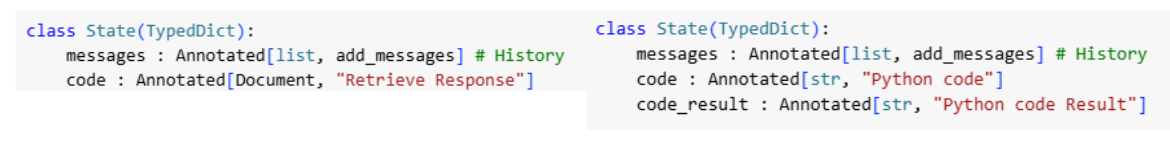

**상태(State)는 에이전트가 현재 어느 단계에 있는지를 나타내는 정보입니다.**  
사용자의 입력, 지금까지의 도구 실행 결과, 다음 작업 지시 등이 모두 상태에 담깁니다.  
상태는 작업이 진행되면서 지속적으로 업데이트되며, 전체 흐름의 컨텍스트 역할을 합니다.  

상태는 단순한 변수가 아니라, 에이전트가 "지금 무엇을 알고 있는가"를 담은 공유 메모리입니다.  
모든 노드는 이 상태를 읽고 쓰기 때문에, 상태 설계가 곧 전체 시스템 설계의 출발점이 됩니다.  

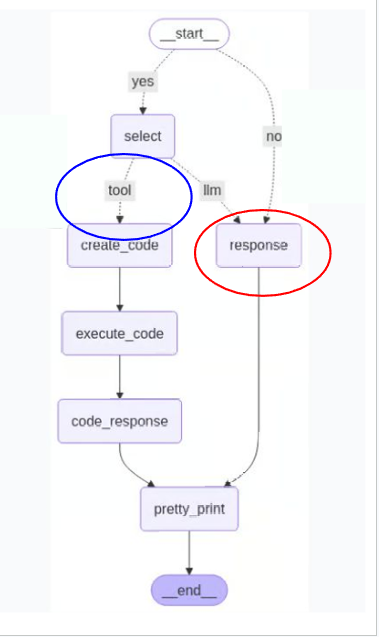

**노드(Node, 그림의 빨간 원)는 하나의 독립적인 작업 단위입니다.**  
각 노드는 현재 상태를 입력받아 정해진 작업을 수행한 뒤, 변경된 상태를 반환합니다.  
예를 들어 "검색 실행", "답변 생성", "결과 검토"와 같은 개별 단계가 각각 하나의 노드가 됩니다.  

노드는 일반 Python 함수로 작성되며, LLM 호출, 도구 실행, 조건 판단 등 어떤 로직도 담을 수 있습니다.  
하나의 노드가 너무 많은 역할을 맡으면 재사용과 디버깅이 어려워지므로, 단일 책임 원칙에 따라 작게 나누는 것이 좋습니다.  

**엣지(Edge)는 노드 간의 흐름을 정의하는 연결선입니다.**  
작업 결과나 상태 조건에 따라 다음에 실행할 노드를 선택하며, 분기·반복·종료와 같은 흐름 제어가 가능합니다.  
조건부 엣지를 활용하면 상황에 따라 서로 다른 경로로 흐름을 유도할 수 있어, LangGraph의 동적인 제어가 가능해집니다.  

정리하면, LangGraph에서 에이전트는 상태를 공유하며 노드를 순서대로 실행하고, 엣지가 그 순서를 동적으로 결정합니다.  
단순한 순차 실행을 넘어 조건 분기와 반복이 가능하기 때문에, 실제 업무 수준의 복잡한 AI 워크플로우를 구현할 수 있습니다.  

LangGraph 기반 데이터 분석 에이전트를 구축하는 간단한 실습을 진행해보겠습니다

- State → Node → Edge 구조로 워크플로우 설계

- 타이타닉 / 올림픽 데이터셋을 활용한 분석 실습
  - history_node → select → code_executor → code_response / response 흐름

In [ ]:
# !pip install langchain langgraph langchain-google-genai langchain-core langchain-community langchain-experimental koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 106.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
# !pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 4.3 MB/s eta 0:00:00


In [6]:
import pandas as pd
import re
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Annotated, Literal, Tuple
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnableConfig
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI

import base64
import io
import os
import warnings

warnings.filterwarnings("ignore")

f:\code\AIFFEL\AIFFEL_study\.venv\lib\site-packages\pydantic\_internal\_generate_schema.py:949: UserWarning: Mixing V1 models and V2 models (or constructs, like `TypeAdapter`) is not supported. Please upgrade `BaseMessage` to V2.
  warnings.warn(


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
from pathlib import Path

# 로컬 노트북에서 Chroma 원격 측정 로그가 시끄럽게 출력되는 것을 막습니다.
os.environ["ANONYMIZED_TELEMETRY"] = "False"

import nest_asyncio
nest_asyncio.apply()


In [3]:
# from google.colab import userdata

# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_KEY')
import os
from pathlib import Path
from dotenv import load_dotenv

# 공용 .env 위치: C:/Users/Administrator/Desktop/workspace/aiffel/.env
env_path = ".env"
load_dotenv(env_path, override=True)

if not os.getenv("OPENAI_API_KEY") and os.getenv("OPENAI_KEY"):
    os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_KEY")

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError(f"OPENAI_API_KEY를 찾지 못했습니다. .env 경로를 확인하세요: {env_path.resolve()}")

In [7]:
# 데이터프레임 불러오기

url = "./content/titanic.csv"
df = pd.read_csv(url)

In [8]:
# 데이터프레임 정보 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 1. State 정의  
LangGraph의 핵심인 State 클래스를 정의합니다. 이 클래스는 에이전트가 실행되는 동안 필요한 모든 정보를 저장합니다:
- `messages`: 대화 히스토리
- `code`: 실행할 Python 코드
- `code_result`: 코드 실행 결과

In [9]:
# 그래프 상태 정의

class State(TypedDict):
    messages : Annotated[list, add_messages] # History
    code : Annotated[str, "Python code"]
    code_result : Annotated[str, "Python code Result"]

ChatGPT 모델을 설정하고, Python 코드 실행 도구를 연결합니다.  
temperature=0은 일관된 응답을 위해 창의성을 최소화합니다.  

도구(Tool)란 LLM이 텍스트 생성 외에 **외부 기능을 실행**할 수 있도록 연결해주는 모듈입니다.  
예를 들어 계산, 코드 실행, 검색 등의 작업을 LLM 스스로 판단하여 호출할 수 있습니다.  
LLM 단독으로는 코드를 실행할 수 없습니다.  
이후 `bind_tools()`를 사용하면 LLM이 필요할 때 직접 도구를 호출할 수 있게 됩니다.  

여기서 정의한 `PythonAstREPLTool`는,
LLM이 파이썬 코드를 직접 실행하고 결과를 받아올 수 있게 해주는 도구입니다.

In [10]:
# LLM 로드

llm =ChatOpenAI(model="gpt-4o-mini",
           temperature=0.)

# llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-preview-04-17",
#                             temperature=0.,
#                             convert_system_message_to_human=True,
#                             )

# 파이썬 코드 실행 도구 정의
tool = PythonAstREPLTool(name="python_repl_ast",
                        description="A Python shell. Use this to execute python commands. \
                                    Input should be a valid python command. When using this tool, \
                                    sometimes output is abbreviated - make sure it does not look abbreviated before using it in your answer.",
                         locals={"df":df})

In [11]:
tool.invoke("```python for i in range(10): print(i)")

'0\n1\n2\n3\n4\n5\n6\n7\n8\n9\n'

### 1-1 Langchain  
기존 랭체인에서의 활용방법을 비교하기 위해 정의된 세션입니다.  
랭그래프로 같은 동작을 하면 어떻게 달라지는지 비교해보세요!  

아래 코드는 데이터프레임(df)을 받아서 LLM(AI)에게 전달하고,
데이터셋에 어울리는 **제목**과 **요약** 을 자동으로 만들어주는 함수입니다.  

. 데이터가 3000행보다 많으면 3000개만 샘플링합니다. AI에게 너무 많은 데이터를 한번에 보내면 비효율적이기 때문입니다.  
2. 프롬프트 템플릿에 데이터를 넣어 AI에게 제목/요약 생성을 요청합니다.  
3. AI의 응답에서 제목과 요약 텍스트만 추출합니다.  
4. 응답 형식이 잘못됐을 경우 기본값("Untitled", "No Summary") 반환합니다.  

In [12]:
# 데이터셋 제목, 요약 생성 함수

def create_title_summary(df:pd.DataFrame) -> Tuple[str, str]:

    # 데이터셋이 너무 클 시 3000개의 샘플만 제공
    df_sampled = df.sample(n=3000) if len(df) > 3000 else df

    prompt = PromptTemplate.from_template("""
            당신은 요약 전문가입니다.

            데이터셋 : {df}

            데이터셋의 정보를 보고 제목과 요약을 만들어냅니다.
            제목은 이 데이터셋을 가장 잘 표현할 수 있는 제목으로 결정하여야합니다.


            제목:
            요약:

            """
            )

    chain = prompt | llm

    # chain.invoke는 AI Message객체를 반환함. 그 중 str 형태인 content만 추출
    result = chain.invoke({"df":df_sampled})

    title = "Untitled"
    summary = "No Summary"

    # 요약 양식에 맞지 않는 답변을 할 시 "Untitle"과 "No Summary"로 설정하도록 예외처리
    try:
        content = result.content
        content = content.replace("## 결과:\n\n", "")
        lines = content.split("\n")
        title = lines[0].replace("## 제목:", "").strip()
        summary = "\n".join(lines[1:]).replace("## 요약:", "").strip()
    except:
        pass

    print("===== 제목, 요약 생성 완료 =====")

    return title, summary

In [13]:
# 제목, 요약 생성

title, summary = create_title_summary(df)

===== 제목, 요약 생성 완료 =====


In [14]:
print("제목 : ", title)
print("요약 : ", summary)

제목 :  **제목:** 타이타닉 승객 생존 데이터셋
요약 :  **요약:** 이 데이터셋은 타이타닉 호의 승객 891명의 정보를 포함하고 있으며, 각 승객의 생존 여부(Survived), 객실 등급(Pclass), 이름(Name), 성별(Sex), 나이(Age), 형제자매 및 배우자 수(SibSp), 부모 및 자녀 수(Parch), 티켓 번호(Ticket), 요금(Fare), 객실 번호(Cabin), 그리고 탑승 항구(Embarked) 등의 특성을 기록하고 있다. 데이터는 생존 분석 및 승객 특성에 대한 통계적 연구에 활용될 수 있다.


LLM에 도구를 쥐어줍니다.

In [15]:
# LLM에게 도구 할당

llm_with_tools = llm.bind_tools([tool])

In [16]:
llm_with_tools.invoke("1부터 10까지  출력하는 파이썬 코드")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mBx6wKxEx5zX9Y383odHjxXc', 'function': {'arguments': '{"query":"for i in range(1, 11):\\n    print(i)"}', 'name': 'python_repl_ast'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 103, 'total_tokens': 134, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_40bf7dabb5', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-2a23b0ce-fed4-404d-ac59-028e263fcf02-0', tool_calls=[{'name': 'python_repl_ast', 'args': {'query': 'for i in range(1, 11):\n    print(i)'}, 'id': 'call_mBx6wKxEx5zX9Y383odHjxXc', 'type': 'tool_call'}], usage_metadata={'input_tokens': 103, 'output_tokens': 31, 'total_tokens': 134})

In [17]:
class HistoryChecker(BaseModel):
    """
    이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
    답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.
    """

    yes_no : Literal["yes", "no"] = Field(..., description="""Use your previous conversation history to determine if you can answer your questions.
    Return "yes" if you can answer, "no" if you can't answer.""")

In [18]:
# LLM의 응답을 HistoryChecker 클래스 구조에 맞춰 파싱하도록 설정

history_checker = llm.with_structured_output(HistoryChecker)

In [19]:
history_checker.invoke("오늘 인천 날씨는 어때?")

HistoryChecker(yes_no='no')

In [20]:
# 히스토리 기반 답변 분기를 위한 함수 설정

def history_check(state:State):

    # 이전 대화가 없으면 무조건 "no" 반환
    if len(state["messages"]) <= 1:
        return "no"

    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변할 수 있는지 판단합니다.
                답변할 수 있다면 "yes", 답변할 수 없다면 "no"를 반환합니다.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | history_checker

    result = chain.invoke({"history":state["messages"][:-1],
                            "query":state["messages"][-1]})

    return result.yes_no

### 2. 워크플로우 노드 함수들
각 노드는 특정 작업을 수행합니다:
- `history_node`: 이전 대화 확인
- `select`: 코드 실행 여부 결정
- `code_executor`: Python 코드 실행
- `code_response`: 결과 정리 및 응답

In [21]:
# 식별을 위한 노드

def history_node(state:State):

    return

In [22]:
# 도구 사용 여부 결정 노드

def select(state:State):
    prompt = PromptTemplate.from_template("""
            당신은 데이터 분석가입니다.
            당신은 데이터프레임인 df를 활용할 수 있습니다.
            당신이 활용 가능한 데이터프레임의 예시는 아래와 같습니다.
            아래의 예시는 `print(df.head())`의 실행결과입니다.
            활용 가능한 데이터프레임을 갖고 있으니 데이터프레임을 새로 생성할 필요 없습니다.
            코드에 한글이 필요하다면 `import koreanize_matplotlib`을 사용하세요.

            당신은 'python_repl_ast'라는 파이썬 코드 실행 도구만을 가지고 있습니다.
            아래의 내용을 참고하여 질문에 대한 코드를 생성합니다.

            df : {df}

            title : {title}
            summary : {summary}

            query : {query}
            """
            )

    chain = prompt | llm_with_tools

    result = chain.invoke({"df": df.head().to_string(), #df.head(),
                           "title":title,
                            "summary":summary,
                            "query":state["messages"][-1].content})

    if hasattr(result, "tool_calls") and len(result.tool_calls) > 0:
        tool_calls = result.tool_calls

        # 코드 추출
        code = tool_calls[0]["args"]["query"]
        return {"code": code}
    else:
        # 도구 사용을 안한다면 코드는 공백으로 설정
        return {"code":""}

In [23]:
# 코드 실행 노드

def code_executor(state:State):

    try:
        # 코드 실행 결과인 이미지 추출
        if "plt" in state["code"] or "sns" in state["code"]:
            save_fig = """
import io
import base64

buf = io.BytesIO()
plt.savefig(buf, format="png")
buf.seek(0)

encoded = base64.b64encode(buf.read()).decode("utf-8")

print(encoded)
"""

            execute_code = state["code"] + save_fig

            result = tool.invoke(execute_code)

            return {"code_result":result}
        # 시각화가 아닌 경우 코드만 실행
        else:
            result = tool.invoke(state["code"])
            return {"code_result":str(result)}
    except:
        return {"code_result": ""}

In [24]:
# 코드에 의한 답변 노드

def code_response(state:State):
    prompt = ChatPromptTemplate.from_messages([
        ("system", """코드 : {code} \n
                    결과 : {code_result}
        당신은 주어진 코드와 코드 결과를 바탕으로 질의에 대해 답변합니다.
        절대 코드에 대해 설명하지마세요.
        독자는 프로그래머가 아닙니다.
        항상 출력되는 값을 기준으로 설명합니다.
        숫자가 매우 중요합니다. 숫자에 대한 정보를 잊지 마세요.
        데이터 분석과 관련된 코드가 입력된다면 항상 인사이트를 포함하세요. """),
        ("human", '{query}')
    ])

    chain = prompt | llm

    result = chain.invoke({"code":state["code"],
                        "code_result":state["code_result"],
                        "query":state["messages"][-1]})

    return { "messages": result}

In [25]:
# 기억 및 일반 응답 노드

def response(state:State):
    prompt = PromptTemplate.from_template("""

                이전의 대화 기록을 참고하여 질문에 대해 답변하세요.
                아래 대화 기록을 첨부합니다.
                대화 기록을 통해 답변이 어렵다면 내부 지식을 참조하세요.

                대화 기록 : {history}

                질문 : {query}

                """)

    chain = prompt | llm

    result = chain.invoke({"history":state["messages"][:-1],
                           "query":state["messages"][-1]})

    return {#"answer":result.content,
            "messages":result}

### 3. 워크플로우 그래프 구축
StateGraph를 사용해 노드들을 연결하고 실행 흐름을 정의합니다.
조건부 엣지를 통해 상황에 따라 다른 경로로 분기할 수 있습니다.

In [26]:
# 그래프 정의

graph_builder = StateGraph(State)

In [27]:
# 노드 및 엣지 정의

graph_builder.add_node("history_node", history_node)
graph_builder.add_node("select", select)
graph_builder.add_node("code_executor", code_executor)
graph_builder.add_node("code_response", code_response)
graph_builder.add_node("response", response)


graph_builder.add_edge(START, "history_node")
graph_builder.add_conditional_edges("history_node",
                                    history_check,
                                    {
                                    "no":"select",
                                     "yes":"response"
                                     }
                                     )
graph_builder.add_edge("select", "code_executor")
graph_builder.add_edge("code_executor", "code_response")
graph_builder.add_edge("code_response", END)
graph_builder.add_edge("response", END);

In [28]:
# 메모리 설정 및 그래프 컴파일
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = graph_builder.compile(checkpointer=memory)

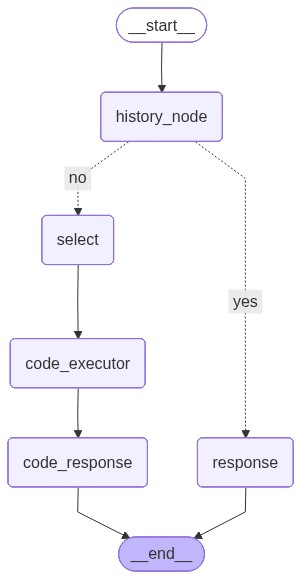

In [29]:
# 그래프 시각화
# 가끔 "ReadTimeout: HTTPSConnectionPool(host='mermaid.ink', port=443): Read timed out. (read timeout=10)"라는 에러가 발생
# 시간 초과로 그래프 생성에 실패했다는 메시지일뿐 기능과는 관계없으니 진행해도 괜찮습니다.

graph

### 4. 에이전트 실행 함수  
사용자 질문을 받아 전체 워크플로우를 실행하고, 실시간으로 결과를 스트리밍합니다.
RunnableConfig로 실행 제한(recursion_limit)을 설정하여 무한 루프를 방지합니다.

In [30]:
# 사용할 설정값 정의

config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "12"})

In [31]:
# 출력 함수 정의
# mode = "values" : 상태의 키, 값의 형태로 반환
# mode = "updates" : 업데이트되는 값만 반환

def streaming(query, config, mode="values"):

    result = graph.stream({"messages":("user", query)}, config=config, stream_mode=mode)

    if mode == "values":
        for step in result:
            for k, v in step.items():
                if k == "messages":
                    v[-1].pretty_print()
                    print("\n\n")
    elif mode == "updates":
        for step in result:
            for k,v in step.items():
                print(f"\n\n=== {k} ===\n\n")
                print(v)

    return

### 5. 데이터 분석 실행 예제 1   
설정된 LangGraph 에이전트를 사용하여 타이타닉 데이터 분석을 수행합니다:
- 생존 여부별 승객 수 분석
- 나이별 승객 분포

================================ Human Message =================================

생존자 비율 시각화하고 인사이트 제공해줘



================================ Human Message =================================

생존자 비율 시각화하고 인사이트 제공해줘





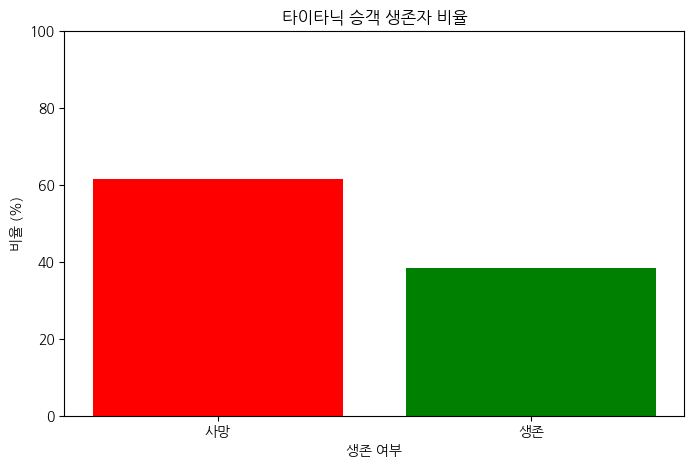

================================ Human Message =================================

생존자 비율 시각화하고 인사이트 제공해줘



================================== Ai Message ==================================

타이타닉 승객의 생존자 비율을 시각화한 결과, 생존자와 사망자의 비율이 각각 나타났습니다. 생존자 비율은 약 38.00%로, 전체 승객 중 1/3 이상이 생존한 것으로 보입니다. 반면, 사망자 비율은 약 62.00%로, 대다수의 승객이 사망한 것으로 나타났습니다.

이 인사이트는 타이타닉 사고의 심각성을 잘 보여주며, 생존자와 사망자의 비율 차이가 크다는 점에서 사고 당시의 상황이 매우 어려웠음을 시사합니다.





<Figure size 640x480 with 0 Axes>

In [32]:
streaming("생존자 비율 시각화하고 인사이트 제공해줘", config)

In [33]:
streaming("아까 내가 질문했던 내용 다시 알려줘", config)

================================ Human Message =================================

아까 내가 질문했던 내용 다시 알려줘



================================== Ai Message ==================================

아까 질문하신 내용은 "생존자 비율 시각화하고 인사이트 제공해줘"였습니다. 이 질문에 대해 생존자 비율은 약 38.00%로, 전체 승객 중 1/3 이상이 생존했으며, 사망자 비율은 약 62.00%로 대다수의 승객이 사망한 것으로 나타났습니다. 이 인사이트는 타이타닉 사고의 심각성을 잘 보여줍니다.





In [34]:
streaming("아까 물어봤던 숫자들 다 더하면 몇인지 알려줘", config)

================================ Human Message =================================

아까 물어봤던 숫자들 다 더하면 몇인지 알려줘



================================== Ai Message ==================================

아까 언급된 생존자 비율은 약 38.00%이고, 사망자 비율은 약 62.00%입니다. 이 두 숫자를 더하면:

38.00 + 62.00 = 100.00

따라서, 생존자 비율과 사망자 비율을 더하면 100.00%입니다.





### 6. 데이터 분석 실행 예제 2  
설정된 LangGraph 에이전트를 재사용하여 데이터 로드와 도구를 재정의, 올림픽 데이터 분석을 수행합니다.  
- 키와 메달 획득 상관관계
- z-score를 활용한 이상치 탐지  
  
올림픽 데이터셋은 여기에서 다운로드 후 사용해주세요!
https://drive.google.com/file/d/1rmDFdDRJ7wT1PXhLnu6jlWyugI3jqmVT/view?usp=sharing

In [36]:
# 올림픽 데이터 로드 및 도구 재정의

url = "./content/athlete_events.csv"
df = pd.read_csv(url)

tool = PythonAstREPLTool(name="python_repl_ast",
                        description="A Python shell. Use this to execute python commands. \
                                    Input should be a valid python command. When using this tool, \
                                    sometimes output is abbreviated - make sure it does not look abbreviated before using it in your answer.",
                        locals={"df":df})


# 제목, 요약 생성
title, summary = create_title_summary(df)

===== 제목, 요약 생성 완료 =====


In [37]:
print("제목 : ", title)
print()
print("요약 : ", summary)

제목 :  **제목:** 올림픽 선수 데이터셋: 인구통계 및 성과 분석

요약 :  **요약:** 이 데이터셋은 3000명의 올림픽 선수에 대한 정보를 포함하고 있으며, 각 선수의 ID, 이름, 성별, 나이, 신장, 체중, 소속 팀, 국가, 경기, 연도, 시즌, 도시, 스포츠, 이벤트 및 메달 수상 여부를 기록하고 있다. 데이터는 여름 및 겨울 올림픽을 포함하며, 다양한 스포츠 종목에서의 선수들의 성과를 분석할 수 있는 기초 자료를 제공한다. 메달 수상 여부는 일부 선수에게만 기록되어 있으며, 이는 선수들의 성과를 평가하는 데 중요한 요소가 된다.


In [38]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "99"})

streaming("올림픽에는 몇개의 나라가 출전했나요?", config)

================================ Human Message =================================

올림픽에는 몇개의 나라가 출전했나요?



================================ Human Message =================================

올림픽에는 몇개의 나라가 출전했나요?



================================ Human Message =================================

올림픽에는 몇개의 나라가 출전했나요?



================================== Ai Message ==================================

올림픽에는 총 230개의 나라가 출전했습니다. 이는 다양한 국가들이 참여하여 국제적인 스포츠 축제를 이루는 것을 의미합니다. 이 숫자는 각 나라의 대표팀이 경쟁하는 만큼, 올림픽의 글로벌한 성격과 다양성을 잘 보여줍니다.





In [39]:
streaming("가장 많이 출전한 나라는 어디인가요?", config)

================================ Human Message =================================

가장 많이 출전한 나라는 어디인가요?



================================== Ai Message ==================================

가장 많이 출전한 나라는 미국입니다. 미국은 올림픽 역사상 가장 많은 메달을 획득한 나라로, 다양한 종목에서 강력한 경쟁력을 보여주고 있습니다.





In [40]:
df["NOC"].value_counts()

NOC
USA    18853
FRA    12758
GBR    12256
ITA    10715
GER     9830
       ...  
YMD        5
SSD        3
NBO        2
UNK        2
NFL        1
Name: count, Length: 230, dtype: int64

In [41]:
streaming("올림픽에 출전한 선수들의 평균 체중은 얼마인가요?", config)

================================ Human Message =================================

올림픽에 출전한 선수들의 평균 체중은 얼마인가요?



================================ Human Message =================================

올림픽에 출전한 선수들의 평균 체중은 얼마인가요?



================================ Human Message =================================

올림픽에 출전한 선수들의 평균 체중은 얼마인가요?



================================== Ai Message ==================================

올림픽에 출전한 선수들의 평균 체중은 약 70.7kg입니다. 이 수치는 선수들의 체중이 대체로 이 정도임을 나타내며, 다양한 종목에서의 체중 분포를 반영할 수 있습니다. 평균 체중이 이 정도라는 것은 특정 종목에서의 체중 관리와 훈련 방식이 선수들의 체중에 영향을 미친다는 것을 시사합니다.





In [42]:
df["Weight"].mean()

np.float64(70.70239290053351)

In [43]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "996"})

streaming("키와 메달 획득과의 상관관계를 보여주세요. regplot 그래프로 그려주세요.", config)

================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. regplot 그래프로 그려주세요.



================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. regplot 그래프로 그려주세요.



================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. regplot 그래프로 그려주세요.



================================== Ai Message ==================================

주어진 데이터에서 키와 메달 획득 여부 간의 상관관계를 분석한 결과, 키가 메달 획득에 미치는 영향을 시각적으로 나타내는 그래프를 생성했습니다. 

이 그래프는 키(Height)와 메달 획득 여부(Medal) 간의 관계를 보여줍니다. 메달을 획득한 선수는 1로 표시되고, 획득하지 않은 선수는 0으로 표시됩니다. 

그래프를 통해 확인할 수 있는 주요 인사이트는 다음과 같습니다:

- 키가 높은 선수들이 메달을 획득할 확률이 상대적으로 높아 보입니다. 
- 특히, 그래프에서 메달을 획득한 선수들은 대체로 키가 180cm 이상인 경우가 많습니다.
- 반면, 키가 낮은 선수들은 메달을 획득하지 않은 경우가 많아 보입니다.

이러한 분석은 선수의 신체적 특성이 성과에 미치는 영향을 이해하는 데 도움을 줄 수 있습니다.





In [44]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "999"})

streaming("키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.", config)

================================ Human Message =================================

키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.



================================ Human Message =================================

키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.



================================ Human Message =================================

키와 체중, 그리고 메달 획득과의 상관관계를 보여주세요. 산점도 그래프로 그려주세요.



================================== Ai Message ==================================

주어진 내용은 키와 체중, 그리고 메달 획득 여부 간의 관계를 시각적으로 표현하는 것입니다. 이 관계를 산점도 그래프로 나타내면, 각 점은 특정한 개인을 나타내며, X축은 키(센티미터 단위), Y축은 체중(킬로그램 단위)을 나타냅니다. 

그래프에서 색상은 메달 획득 여부를 나타내며, 메달을 획득한 경우는 한 색상(예: 노란색)으로, 미획득한 경우는 다른 색상(예: 보라색)으로 표시됩니다. 이를 통해 키와 체중이 메달 획득에 어떤 영향을 미치는지를 시각적으로 분석할 수 있습니다.

이러한 시각화는 데이터 분석에서 중요한 인사이트를 제공합니다. 예를 들어, 특정 키와 체중 범위에서 메달을 획득한 선수들이 집중되어 있다면, 해당 범위가 메달 획득에 긍정적인 영향을 미칠 수 있다는 가설을 세울 수 있습니다. 반대로, 메달을 획득하지 못한 선수들이 특정한 키와 체중 범위에 몰려 있다면, 그 범위가 메달 획득에 부정적인 영향을 미칠 수 있습니다. 

이러한 분석은 스포츠 과학, 훈련 방법 개선, 선수 선발 과정 등 다양한 분

================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. boxplot 그래프로 그려주세요. 그리고 그래프에서 이상치로 보이는 선수들의 목록을 z-score나 IQR 방법을 사용해서 찾아서 표로 보여주세요.



================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. boxplot 그래프로 그려주세요. 그리고 그래프에서 이상치로 보이는 선수들의 목록을 z-score나 IQR 방법을 사용해서 찾아서 표로 보여주세요.



================================ Human Message =================================

키와 메달 획득과의 상관관계를 보여주세요. boxplot 그래프로 그려주세요. 그리고 그래프에서 이상치로 보이는 선수들의 목록을 z-score나 IQR 방법을 사용해서 찾아서 표로 보여주세요.



================================== Ai Message ==================================

주어진 코드에서 키와 메달 획득 간의 상관관계를 시각화하려고 했지만, 오류가 발생했습니다. 이 오류는 데이터의 구조나 내용에 문제가 있을 때 발생할 수 있습니다. 

이상치를 찾기 위해 z-score 또는 IQR 방법을 사용할 수 있습니다. 

1. **Z-score 방법**: 각 선수의 키에서 평균 키를 빼고, 이를 표준편차로 나누어 z-score를 계산합니다. 일반적으로 z-score가 3을 초과하는 경우를 이상치로 간주합니다.

2. **IQR 방법**: 키의 1사분위수(Q1)와 3사분위수(Q3)를 계산한 후, IQR(Interquartile Range)을 구합니다. IQR은 Q3 - Q1로 정

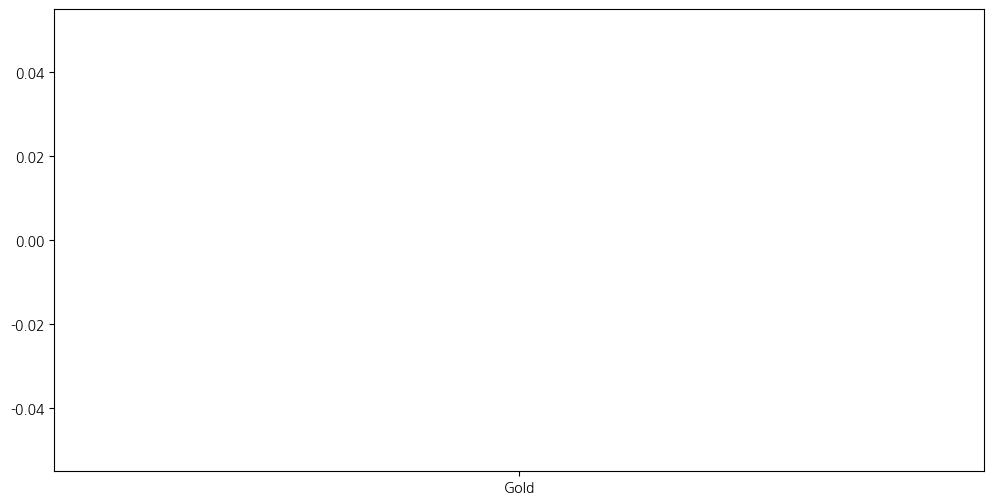

In [45]:
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "985"})

streaming("키와 메달 획득과의 상관관계를 보여주세요. boxplot 그래프로 그려주세요. 그리고 그래프에서 이상치로 보이는 선수들의 목록을 z-score나 IQR 방법을 사용해서 찾아서 표로 보여주세요.", config)
